<a href="https://colab.research.google.com/github/dhanusharer/DL-practise/blob/main/keras02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Word Embeddings with Keras
### From One-Hot Encoding to Dense Vector Representations

---

**Author:** Dhanush  
**Framework:** TensorFlow / Keras  
**Topic:** Natural Language Processing (NLP) — Text Representation  

---

## 📌 Objective

Understand two fundamental ways to represent text numerically for deep learning:

1. **One-Hot Encoding** — simple integer hashing of words into a large vocabulary space
2. **Word Embeddings** — dense, trainable vector representations that capture semantic meaning

## 🗂️ Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Define Sample Sentences |
| 3 | One-Hot Encoding |
| 4 | Padding Sequences |
| 5 | Build Embedding Model |
| 6 | Inspect Embeddings |
| 7 | Summary & Key Concepts |

---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.models import Sequential

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


---
## Step 2 — Define Sample Sentences

We use a small corpus of 6 sentences to demonstrate text preprocessing. In a real project, this would be thousands of sentences loaded from a dataset.

In [2]:
sentences = [
    'the glass of milk',
    'the glass of juice',
    'I am a good boy',
    'I am a good developer',
    'understanding the meaning of words',
    'your videos are good',
]

print(f"Corpus size   : {len(sentences)} sentences")
print(f"Unique words  : {len(set(' '.join(sentences).lower().split()))}")
print("\nSentences:")
for i, s in enumerate(sentences, 1):
    print(f"  {i}. '{s}'  ({len(s.split())} words)")

Corpus size   : 6 sentences
Unique words  : 17

Sentences:
  1. 'the glass of milk'  (4 words)
  2. 'the glass of juice'  (4 words)
  3. 'I am a good boy'  (5 words)
  4. 'I am a good developer'  (5 words)
  5. 'understanding the meaning of words'  (5 words)
  6. 'your videos are good'  (4 words)


---
## Step 3 — One-Hot Encoding

### What is One-Hot Encoding?

Keras's `one_hot()` uses a **hashing trick**: each word is hashed to an integer in the range `[1, voc_size]`. This is different from a true one-hot vector — it returns just the **integer index**, not a sparse binary vector.

```
"the glass of milk"  →  [9864, 194, 88, 4945]
```

### Why `voc_size = 10000`?

The vocabulary size acts as the **hash space**. A larger value reduces the chance of **hash collisions** (two different words mapping to the same integer). For a small corpus like ours, 10,000 is more than enough.

> ⚠️ **Limitation of One-Hot:** These integer indices carry no semantic meaning. The number 9864 for "the" and 194 for "glass" don't tell us anything about their relationship. This is exactly the problem that Word Embeddings solve.

In [3]:
VOC_SIZE = 10000

# Encode each sentence: each word → integer index
onehot_repr = [one_hot(sentence, VOC_SIZE) for sentence in sentences]

print(f"Vocabulary (hash) size : {VOC_SIZE}")
print("\nOne-Hot Encoded Sentences:")
for original, encoded in zip(sentences, onehot_repr):
    print(f"  '{original}'")
    print(f"   → {encoded}\n")

Vocabulary (hash) size : 10000

One-Hot Encoded Sentences:
  'the glass of milk'
   → [3763, 5718, 6592, 4245]

  'the glass of juice'
   → [3763, 5718, 6592, 7319]

  'I am a good boy'
   → [7324, 3912, 7231, 3936, 9401]

  'I am a good developer'
   → [7324, 3912, 7231, 3936, 1186]

  'understanding the meaning of words'
   → [2989, 3763, 666, 6592, 6799]

  'your videos are good'
   → [6564, 6547, 5069, 3936]



---
## Step 4 — Padding Sequences

### Why Do We Need Padding?

Neural networks require **fixed-size inputs**. Our sentences have different lengths (4–5 words), so we pad all of them to the same length using zeros.

| Padding Type | Zeros Added |
|---|---|
| `'pre'` (used here) | Before the sequence: `[0, 0, 0, 0, word1, word2, ...]` |
| `'post'` | After the sequence: `[word1, word2, ..., 0, 0, 0, 0]` |

We use `sent_length = 8` — the maximum length we want to support.

In [4]:
SENT_LENGTH = 8  # All sequences padded/truncated to this length

padded_docs = pad_sequences(onehot_repr, padding='pre', maxlen=SENT_LENGTH)

print(f"Sequence length after padding : {SENT_LENGTH}")
print(f"Padded matrix shape           : {padded_docs.shape}  (sentences × words)")
print("\nPadded Sequences (zeros = padding):")
for i, (sentence, padded) in enumerate(zip(sentences, padded_docs)):
    print(f"  '{sentence}'")
    print(f"   → {padded}\n")

Sequence length after padding : 8
Padded matrix shape           : (6, 8)  (sentences × words)

Padded Sequences (zeros = padding):
  'the glass of milk'
   → [   0    0    0    0 3763 5718 6592 4245]

  'the glass of juice'
   → [   0    0    0    0 3763 5718 6592 7319]

  'I am a good boy'
   → [   0    0    0 7324 3912 7231 3936 9401]

  'I am a good developer'
   → [   0    0    0 7324 3912 7231 3936 1186]

  'understanding the meaning of words'
   → [   0    0    0 2989 3763  666 6592 6799]

  'your videos are good'
   → [   0    0    0    0 6564 6547 5069 3936]



---
## Step 5 — Build the Embedding Model

### What is a Word Embedding?

An **Embedding layer** maps each integer index to a **dense vector** of fixed size (`embedding_dim`). These vectors are learned during training — words used in similar contexts will end up with similar vectors.

```
word index 9864 ("the")  →  [-0.041, -0.035, 0.037, ..., -0.041]  (10 values)
```

### Embedding Layer Parameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `input_dim` | `VOC_SIZE` (10000) | Size of the vocabulary (hash space) |
| `output_dim` | `EMBEDDING_DIM` (10) | Size of each embedding vector |
| **Total params** | `10000 × 10 = 100,000` | One 10-d vector per vocabulary word |

The output shape for one sentence of length 8 is: **`(8, 10)`** — 8 words, each with a 10-dimensional vector.

In [5]:
EMBEDDING_DIM = 10  # Each word → 10-dimensional dense vector

model = Sequential([
    Input(shape=(SENT_LENGTH,)),
    Embedding(input_dim=VOC_SIZE, output_dim=EMBEDDING_DIM, name='embedding_layer')
])

model.compile(optimizer='adam', loss='mse')
model.summary()

print(f"\nEmbedding table shape : ({VOC_SIZE} words × {EMBEDDING_DIM} dims) = {VOC_SIZE * EMBEDDING_DIM:,} parameters")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 8, 10)          │       100,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,000 (390.62 KB)

 Trainable params: 100,000 (390.62 KB)

 Non-trainable params: 0 (0.00 B)


Embedding table shape : (10000 words × 10 dims) = 100,000 parameters


---
## Step 6 — Inspect the Embeddings

Before any training, the embedding weights are **randomly initialized**. After training on a task (e.g., sentiment classification), these vectors shift so that semantically similar words have similar vectors.

Here we just verify the output shape and examine what the raw vectors look like.

In [6]:
# Get embeddings for all padded sentences
embeddings_output = model.predict(padded_docs, verbose=0)

print(f"Output shape : {embeddings_output.shape}")
print(f"  → ({len(sentences)} sentences  ×  {SENT_LENGTH} words  ×  {EMBEDDING_DIM} embedding dims)")

Output shape : (6, 8, 10)
  → (6 sentences  ×  8 words  ×  10 embedding dims)


In [7]:
# Inspect embedding for the first sentence
sentence_idx = 0
print(f"Sentence     : '{sentences[sentence_idx]}'")
print(f"Padded input : {padded_docs[sentence_idx]}")
print(f"\nEmbedding matrix (shape {embeddings_output[sentence_idx].shape}):")
print(f"{'Token Index':>12}  {'Embedding Vector (10 dims)':>15}")
print("-" * 60)
for token, vector in zip(padded_docs[sentence_idx], embeddings_output[sentence_idx]):
    vec_str = ' '.join(f'{v:6.3f}' for v in vector)
    label = '[PAD]' if token == 0 else f'idx={token}'
    print(f"  {label:>10}  [{vec_str}]")

Sentence     : 'the glass of milk'
Padded input : [   0    0    0    0 3763 5718 6592 4245]

Embedding matrix (shape (8, 10)):
 Token Index  Embedding Vector (10 dims)
------------------------------------------------------------
       [PAD]  [ 0.000  0.048 -0.002  0.039  0.047 -0.013 -0.006 -0.047  0.033 -0.039]
       [PAD]  [ 0.000  0.048 -0.002  0.039  0.047 -0.013 -0.006 -0.047  0.033 -0.039]
       [PAD]  [ 0.000  0.048 -0.002  0.039  0.047 -0.013 -0.006 -0.047  0.033 -0.039]
       [PAD]  [ 0.000  0.048 -0.002  0.039  0.047 -0.013 -0.006 -0.047  0.033 -0.039]
    idx=3763  [ 0.010  0.044  0.034 -0.005  0.020 -0.023  0.027  0.014  0.022  0.019]
    idx=5718  [-0.011  0.014 -0.037 -0.003  0.032  0.017  0.046  0.008  0.037 -0.015]
    idx=6592  [ 0.033 -0.025  0.032 -0.030  0.016 -0.026 -0.010 -0.016  0.038  0.047]
    idx=4245  [ 0.011  0.001  0.017 -0.018  0.032  0.002  0.033 -0.030  0.024 -0.007]


Token index for 'the' in sentence 0: 3763
Token index for 'the' in sentence 1: 3763
Same index? True  ← Same word = same embedding vector


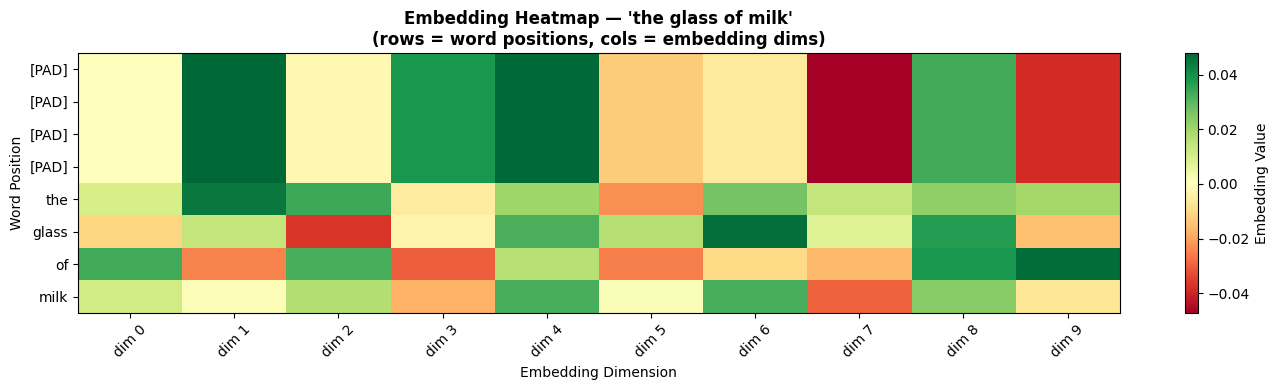

In [8]:
# Compare embeddings of the same word across sentences
# "the" appears in sentences 0, 1, and 4 — its embedding should be identical
# (same index = same row in the embedding lookup table)

import matplotlib.pyplot as plt

# Find 'the' index in each sentence
the_idx_s0 = padded_docs[0][4]  # 'the' in sentence 0
the_idx_s1 = padded_docs[1][4]  # 'the' in sentence 1

print(f"Token index for 'the' in sentence 0: {the_idx_s0}")
print(f"Token index for 'the' in sentence 1: {the_idx_s1}")
print(f"Same index? {the_idx_s0 == the_idx_s1}  ← Same word = same embedding vector")

# Visualize embedding vectors as a heatmap
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(embeddings_output[0], cmap='RdYlGn', aspect='auto')
ax.set_title(f"Embedding Heatmap — '{sentences[0]}'\n(rows = word positions, cols = embedding dims)",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Word Position')
word_labels = ['[PAD]'] * 4 + sentences[0].split()
ax.set_yticks(range(SENT_LENGTH))
ax.set_yticklabels(word_labels)
ax.set_xticks(range(EMBEDDING_DIM))
ax.set_xticklabels([f'dim {i}' for i in range(EMBEDDING_DIM)], rotation=45)
plt.colorbar(im, ax=ax, label='Embedding Value')
plt.tight_layout()
plt.show()

---
## 📊 Summary & Key Concepts

### Pipeline Recap

```
Raw Text
  ↓  one_hot(sentence, VOC_SIZE)
Integer Indices  (variable length lists)
  ↓  pad_sequences(..., maxlen=8, padding='pre')
Padded Integer Matrix  (6 × 8)
  ↓  Embedding(VOC_SIZE, EMBEDDING_DIM)
Dense Embedding Tensor  (6 × 8 × 10)
```

### Comparison: One-Hot vs Embeddings

| Feature | One-Hot Encoding | Word Embeddings |
|---------|------------------|-----------------|
| Representation | Sparse integer index | Dense vector |
| Dimensionality | `voc_size` (10,000+) | Small (10–300) |
| Semantic info | ❌ None | ✅ Learned from data |
| Trainable | ❌ Fixed | ✅ Updated via backprop |
| Memory | Efficient (just an int) | Efficient (small dense vector) |

### Key Takeaways

| Concept | What Was Learned |
|---------|------------------|
| **one_hot()** | Hashes each word to an integer — fast but no semantics |
| **pad_sequences()** | Makes variable-length sequences uniform for batch training |
| **Embedding layer** | Lookup table: integer → dense vector, learned end-to-end |
| **Output shape** | `(batch, seq_len, embed_dim)` — a 3D tensor |
| **Hash collisions** | Two words may share an index if `voc_size` is too small |

### Next Steps to Explore

- 🔗 Use **pre-trained embeddings** like GloVe or Word2Vec (`Embedding(..., weights=[glove_matrix], trainable=False)`)
- 🧱 Stack an **LSTM or GRU** after the Embedding layer for sequence classification
- 📊 Use **t-SNE** to visualize trained embedding vectors in 2D and see word clusters
- 🏷️ Apply to a real task: **sentiment analysis** or **text classification**

---
*This notebook is part of a Deep Learning practice series. See more at [github.com/dhanusharer/DL-practise](https://github.com/dhanusharer/DL-practise)*